In [49]:
import pandas as pd
import os

In [50]:

df = pd.read_csv("../data/features_data.csv")

In [51]:
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [52]:
X = df.drop("lifesat", axis=1)
y = df["lifesat"]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression MAE: 0.7439083518939844


In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
print("Random Forest MAE:", mae_rf)

Random Forest MAE: 0.7508413001912044


In [56]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, pred_xgb)
print("XGBoost MAE:", mae_xgb)

XGBoost MAE: 0.8352283612036112


In [57]:
print(f"""
Linear Regression MAE: {mae_lr}
Random Forest MAE: {mae_rf}
XGBoost MAE: {mae_xgb}
""")


Linear Regression MAE: 0.7439083518939844
Random Forest MAE: 0.7508413001912044
XGBoost MAE: 0.8352283612036112



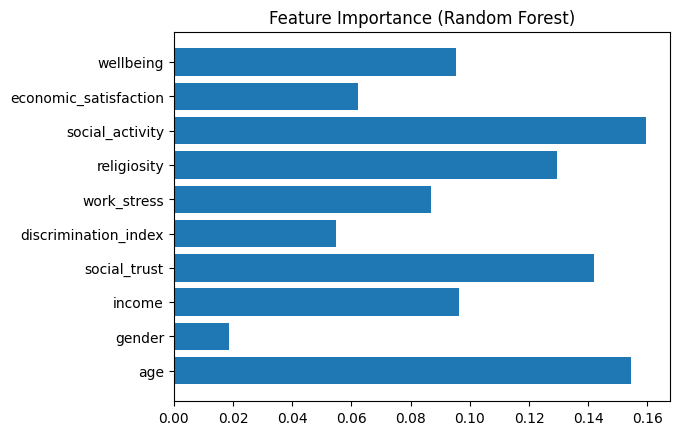

In [58]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.savefig(f"{RESULTS_DIR}/feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
import shap

In [60]:
explainer = shap.Explainer(xgb)

In [61]:
shap_values = explainer(X_test)

In [62]:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig(f"{RESULTS_DIR}/shap_summary.png", dpi=300, bbox_inches="tight")
plt.close()

In [63]:
shap.plots.bar(shap_values, show=False)
plt.savefig(f"{RESULTS_DIR}/shap_bar.png", dpi=300, bbox_inches="tight")
plt.close()

In [64]:
shap.plots.waterfall(shap_values[0],show=False)
plt.savefig(f"{RESULTS_DIR}/shap_bar_waterfall.png",dpi=300, bbox_inches="tight")
plt.close()